# Predicción de Demanda de Pasajeros - Red de Subterráneos CABA
## Trabajo Final Integrador - V3 SIMPLIFICADO

Carga directa desde Parquet - Sin conversiones

In [1]:
import pandas as pd
import numpy as np
import warnings
warnings.filterwarnings('ignore')

import matplotlib.pyplot as plt
import seaborn as sns
import plotly.graph_objects as go
import plotly.express as px
from scipy import stats
import os
import gc

from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from xgboost import XGBRegressor

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense
from tensorflow.keras.callbacks import EarlyStopping

sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (14, 6) 

## 1. Cargar datos desde Parquet

In [2]:
parquet_dir = "./data_parquet"
data_files = {}

print("Cargando archivos Parquet...\n")

parquet_files = sorted([f for f in os.listdir(parquet_dir) if f.endswith('.parquet')])

for pfile in parquet_files:
    filepath = os.path.join(parquet_dir, pfile)
    try:
        df = pd.read_parquet(filepath)
        name = pfile.replace('.parquet', '.csv')
        data_files[name] = df
        print(f"✓ {name:<50} {df.shape}")
        gc.collect()
    except Exception as e:
        print(f"✗ {pfile}: {e}")

print(f"\nTotal: {len(data_files)} archivos cargados")
total_memory = sum(df.memory_usage(deep=True).sum() for df in data_files.values()) / 1024**3
print(f"Memoria: {total_memory:.2f} GB")

Cargando archivos Parquet...

✓ BaseUnificadaEstaciones.csv                        (822363, 6)
✓ estaciones-accesibles.csv                          (93, 6)
✓ historico_2014.csv                                 (2171449, 11)
✓ historico_2015.csv                                 (2191716, 11)
✓ historico_2016.csv                                 (2308464, 11)
✓ historico_2017.csv                                 (2387695, 12)
✓ historico_2018.csv                                 (2427291, 11)
✓ historico_2019.csv                                 (2532469, 11)
✓ historico_2020.csv                                 (1156201, 10)
✓ historico_2021.csv                                 (1614336, 11)
✓ lineas-de-subte.csv                                (82, 3)
✓ registro-historico-del-precio-del-boleto.csv       (304, 4)
✓ viajes_anual.csv                                   (48, 3)

Total: 13 archivos cargados
Memoria: 2.46 GB


## 2. Consolidación de históricos

In [3]:
print("\nConsolidando históricos 2014-2021...")

historicos = [f for f in data_files.keys() if f.startswith('historico_')]
historicos_list = [data_files[f] for f in sorted(historicos)]

df_consolidado = pd.concat(historicos_list, ignore_index=True, sort=False)
data_files['historico_consolidado_2014_2021.csv'] = df_consolidado

print(f"Consolidado: {df_consolidado.shape}")
print(f"Memoria: {df_consolidado.memory_usage(deep=True).sum() / 1024**3:.2f} GB")

df_main = df_consolidado.sample(frac=0.5, random_state=42).reset_index(drop=True)
del df_consolidado
gc.collect()

print(f"Dataset completo (100%): {df_main.shape}")


Consolidando históricos 2014-2021...
Consolidado: (16789621, 27)
Memoria: 4.41 GB
Dataset completo (100%): (8394810, 27)


## 3. Relacionamiento de datos

In [4]:
print("\nRelacionando datasets...")

# Normalizar columnas
df_main.columns = df_main.columns.str.lower().str.strip()

# Corregir columnas duplicadas (evita errores de merge por labels no únicos)
def make_unique_columns(df):
    cols = []
    counts = {}
    for c in df.columns:
        c = str(c)
        counts[c] = counts.get(c, 0) + 1
        cols.append(c if counts[c] == 1 else f"{c}__dup{counts[c]-1}")
    df = df.copy()
    df.columns = cols
    return df

if not df_main.columns.is_unique:
    dup_cols_main = df_main.columns[df_main.columns.duplicated()].tolist()
    print(f"⚠ Columnas duplicadas en df_main detectadas: {sorted(set(dup_cols_main))}")
    df_main = make_unique_columns(df_main)

# Consolidar columnas duplicadas de distintos años (MAYÚSCULAS vs minúsculas → mismo nombre)
_cols_clave = ['fecha', 'linea', 'molinete', 'estacion',
               'pax_total', 'total', 'pax_pagos', 'pax_pases_pagos', 'pax_franq']
for _base in _cols_clave:
    _dupes = [c for c in df_main.columns
              if c == _base or c.startswith(f'{_base}__dup')]
    if len(_dupes) > 1:
        df_main[_base] = df_main[_dupes].bfill(axis=1).iloc[:, 0]
        df_main.drop(columns=[c for c in _dupes if c != _base], inplace=True, errors='ignore')
        print(f"  ✓ Consolidadas {len(_dupes)} versiones de '{_base}'")

# Normalización de valores para merge (acentos, mayúsculas, prefijo "Linea")
import re as _re

def norm_estacion_val(s):
    s = str(s).strip().upper()
    for k, v in {'Á':'A','À':'A','É':'E','È':'E','Í':'I','Ì':'I',
                 'Ó':'O','Ò':'O','Ú':'U','Ù':'U','Ñ':'N'}.items():
        s = s.replace(k, v)
    return s

def norm_linea_val(s):
    # "LineaA" -> "A", "linea_b" -> "B", "A" -> "A"
    s = _re.sub(r'(?i)^linea[_\s]*', '', str(s).strip()).strip().upper()
    return s

# Merge con estaciones
df_estaciones = data_files.get('estaciones-accesibles.csv')
if df_estaciones is not None:
    df_estaciones.columns = df_estaciones.columns.str.lower().str.strip()
    if not df_estaciones.columns.is_unique:
        df_estaciones = make_unique_columns(df_estaciones)

    def first_matching_col(df, base_name):
        matches = [c for c in df.columns if str(c) == base_name or str(c).startswith(f"{base_name}__dup")]
        return matches[0] if matches else None

    def normalize_colname(text):
        text = str(text).lower().strip()
        repl = {'á':'a','à':'a','ä':'a','â':'a','ã':'a','å':'a','ā':'a',
                'é':'e','è':'e','ë':'e','ê':'e','ē':'e',
                'í':'i','ì':'i','ï':'i','î':'i','ī':'i',
                'ó':'o','ò':'o','ö':'o','ô':'o','õ':'o','ō':'o',
                'ú':'u','ù':'u','ü':'u','û':'u','ū':'u','ñ':'n'}
        for k, v in repl.items():
            text = text.replace(k, v)
        return ''.join(ch for ch in text if ch.isalnum() or ch == '_')

    def find_col_by_aliases(df, aliases):
        alias_norm = {normalize_colname(a) for a in aliases}
        for c in df.columns:
            cn = normalize_colname(c)
            if cn in alias_norm:
                return c
        for c in df.columns:
            cn = normalize_colname(c)
            if any(cn.startswith(a) for a in alias_norm):
                return c
        return None

    main_est = first_matching_col(df_main, 'estacion')
    main_lin = first_matching_col(df_main, 'linea')
    est_est = first_matching_col(df_estaciones, 'estacion')
    est_lin = first_matching_col(df_estaciones, 'linea')

    if all([main_est, main_lin, est_est, est_lin]) and {'lat', 'long'}.issubset(df_estaciones.columns):
        # Normalizar claves de merge en ambos datasets
        df_main['_estacion_key'] = df_main[main_est].apply(norm_estacion_val)
        df_main['_linea_key'] = df_main[main_lin].apply(norm_linea_val)

        estaciones_ref = df_estaciones[[est_est, est_lin, 'lat', 'long']].copy()
        estaciones_ref = estaciones_ref.rename(columns={est_est: '_estacion_key', est_lin: '_linea_key'})
        estaciones_ref['_estacion_key'] = estaciones_ref['_estacion_key'].apply(norm_estacion_val)
        estaciones_ref['_linea_key'] = estaciones_ref['_linea_key'].apply(norm_linea_val)

        # Unicidad de claves
        estaciones_ref = estaciones_ref.drop_duplicates(subset=['_estacion_key', '_linea_key'])

        # Debug: verificar coverage del merge
        main_keys = set(zip(df_main['_estacion_key'], df_main['_linea_key']))
        est_keys = set(zip(estaciones_ref['_estacion_key'], estaciones_ref['_linea_key']))
        matched = main_keys & est_keys
        print(f"  Claves únicas en datos: {len(main_keys)}, en estaciones: {len(est_keys)}, matchean: {len(matched)}")

        # Evitar conflictos de sufijos por columnas geográficas previas
        geo_cols = [
            c for c in df_main.columns
            if str(c) in ['lat', 'long', 'lat_x', 'lat_y', 'long_x', 'long_y']
            or str(c).startswith('lat__dup') or str(c).startswith('long__dup')
        ]
        if geo_cols:
            df_main = df_main.drop(columns=geo_cols, errors='ignore')

        df_main = df_main.merge(estaciones_ref, on=['_estacion_key', '_linea_key'], how='left')
        df_main.drop(columns=['_estacion_key', '_linea_key'], inplace=True, errors='ignore')

        pct_con_coords = df_main['lat'].notna().mean() * 100
        print(f"✓ Coordenadas agregadas ({pct_con_coords:.1f}% de filas con lat/long)")
    else:
        print("⚠ No se pudo hacer merge con estaciones (faltan columnas clave)")

# Merge con tarifas
df_tarifas = data_files.get('registro-historico-del-precio-del-boleto.csv')
if df_tarifas is not None and 'fecha' in df_main.columns:
    df_main['fecha'] = pd.to_datetime(df_main['fecha'], errors='coerce')
    df_main['año'] = df_main['fecha'].dt.year
    df_main['mes'] = df_main['fecha'].dt.month
    
    df_tarifas.columns = df_tarifas.columns.str.lower().str.strip()
    if not df_tarifas.columns.is_unique:
        df_tarifas = make_unique_columns(df_tarifas)

    col_ano = find_col_by_aliases(df_tarifas, ['año', 'ano', 'anio', 'anio'])
    col_mes = find_col_by_aliases(df_tarifas, ['mes_numero', 'mesnumero', 'mes'])
    col_precio = find_col_by_aliases(df_tarifas, ['precio', 'valor', 'tarifa'])

    if all([col_ano, col_mes, col_precio]):
        tarifas_ref = df_tarifas[[col_ano, col_mes, col_precio]].copy()
        tarifas_ref = tarifas_ref.rename(columns={col_ano: 'año', col_mes: 'mes', col_precio: 'precio'})

        tarifas_ref['año'] = pd.to_numeric(tarifas_ref['año'], errors='coerce')
        tarifas_ref['mes'] = pd.to_numeric(tarifas_ref['mes'], errors='coerce')
        tarifas_ref['precio'] = pd.to_numeric(tarifas_ref['precio'], errors='coerce')

        tarifas_ref = tarifas_ref.drop_duplicates(subset=['año', 'mes'])

        if 'precio' in df_main.columns:
            df_main.drop(columns=['precio'], inplace=True, errors='ignore')

        df_main = df_main.merge(tarifas_ref, on=['año', 'mes'], how='left')
        df_main['precio'] = df_main.groupby('año')['precio'].transform(lambda x: x.ffill().bfill())
        print("✓ Tarifas agregadas")
    else:
        print(f"⚠ No se pudo hacer merge con tarifas. Columnas detectadas: año={col_ano}, mes={col_mes}, precio={col_precio}")

print(f"Dataset: {df_main.shape}")



Relacionando datasets...
⚠ Columnas duplicadas en df_main detectadas: ['desde', 'estacion', 'fecha', 'hasta', 'linea', 'molinete', 'pax_franq', 'pax_pagos', 'pax_pases_pagos', 'pax_total', 'total']
  ✓ Consolidadas 2 versiones de 'fecha'
  ✓ Consolidadas 2 versiones de 'linea'
  ✓ Consolidadas 2 versiones de 'molinete'
  ✓ Consolidadas 2 versiones de 'estacion'
  ✓ Consolidadas 2 versiones de 'pax_total'
  ✓ Consolidadas 2 versiones de 'total'
  ✓ Consolidadas 2 versiones de 'pax_pagos'
  ✓ Consolidadas 2 versiones de 'pax_pases_pagos'
  ✓ Consolidadas 2 versiones de 'pax_franq'
  Claves únicas en datos: 111, en estaciones: 85, matchean: 74
✓ Coordenadas agregadas (81.9% de filas con lat/long)
⚠ No se pudo hacer merge con tarifas. Columnas detectadas: año=None, mes=mes_numero, precio=precio
Dataset: (8394810, 22)


## 4. Identificar variable objetivo

In [ ]:
print("\nIdentificando variable objetivo...")

target_col = None
for col in ['pax_total', 'total', 'cantidad', 'pax_pagos', 'pax_pases_pagos']:
    if col in df_main.columns:
        df_main[col] = pd.to_numeric(df_main[col], errors='coerce')
        non_null = df_main[col].notna().sum()
        if target_col is None or non_null > df_main[target_col].notna().sum():
            target_col = col
0
if target_col:
    print(f"✓ Variable objetivo: {target_col}")
    print(f"  Media: {df_main[target_col].mean():.2f}")
    print(f"  Mediana: {df_main[target_col].median():.2f}")
else:
    print("✗ No se identificó variable objetivo")
    target_col = 'pax_total'


Identificando variable objetivo...
✓ Variable objetivo: pax_pases_pagos
  Media: 0.13
  Mediana: 0.00


## 5. EDA - Gráficos principales


Generando visualizaciones...



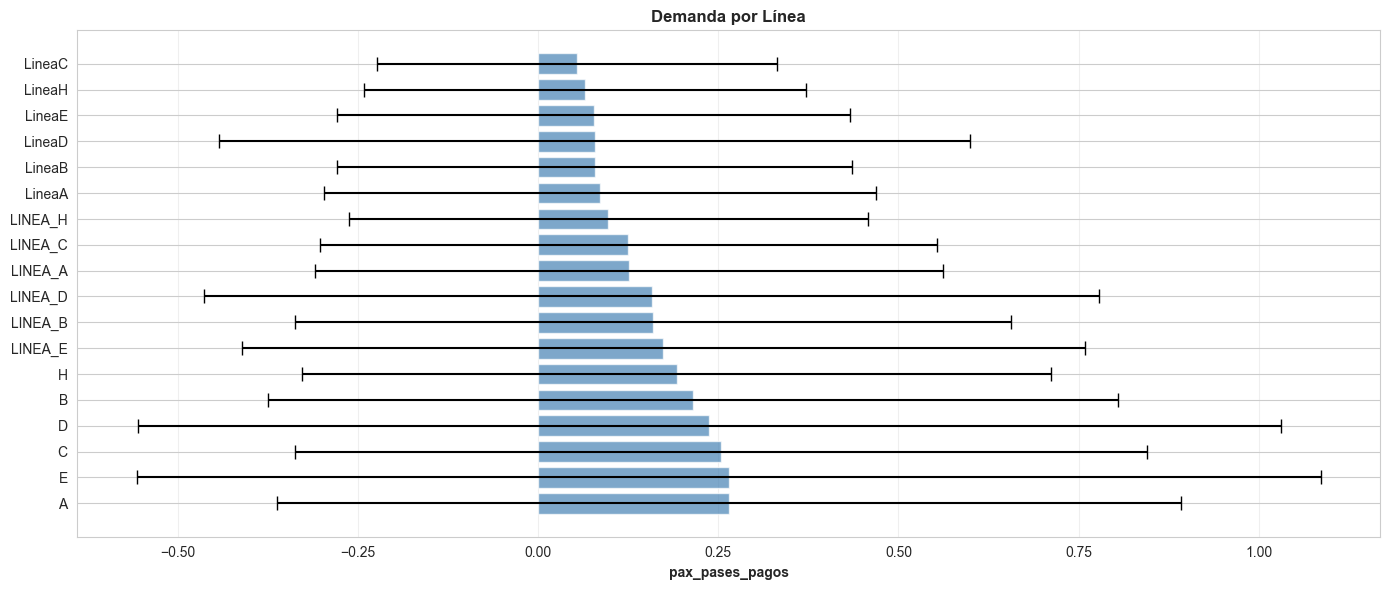

In [6]:
print("\nGenerando visualizaciones...\n")

# Gráfico 1: Demanda por línea
if target_col and 'linea' in df_main.columns:
    fig, ax = plt.subplots(figsize=(14, 6))
    by_line = df_main.groupby('linea')[target_col].agg(['mean', 'std']).sort_values('mean', ascending=False)
    ax.barh(by_line.index, by_line['mean'], xerr=by_line['std'], capsize=5, alpha=0.7, color='steelblue')
    ax.set_xlabel(f'{target_col}', fontweight='bold')
    ax.set_title('Demanda por Línea', fontweight='bold')
    ax.grid(axis='x', alpha=0.3)
    plt.tight_layout()
    plt.show()

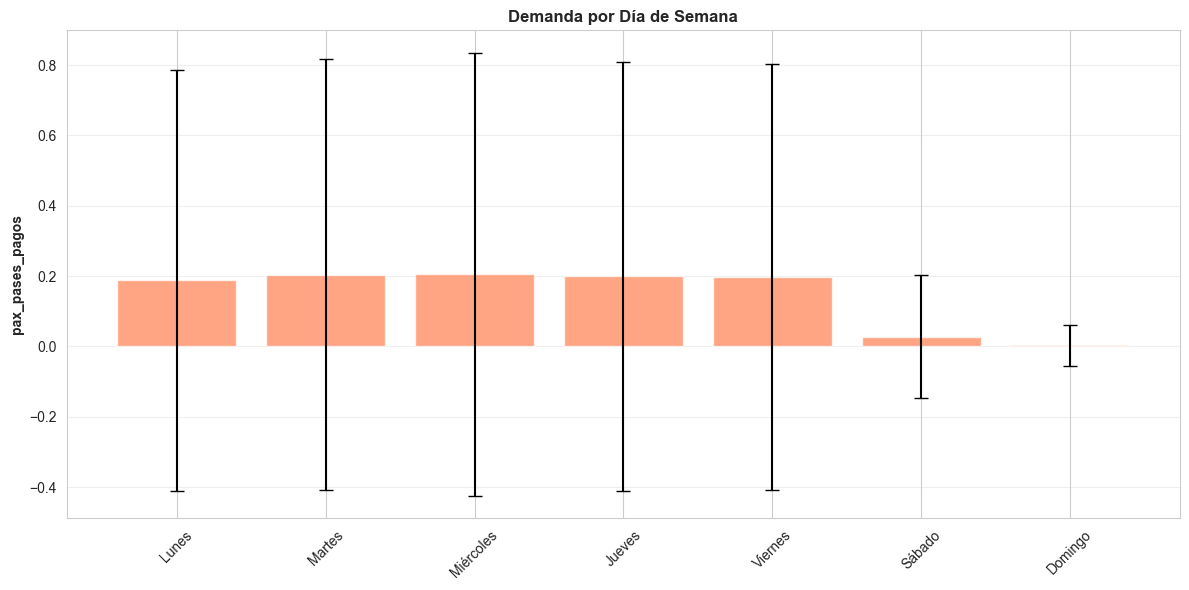

In [7]:
# Gráfico 2: Demanda por día de semana
if 'fecha' in df_main.columns and target_col:
    df_main['dia_semana'] = df_main['fecha'].dt.dayofweek
    
    fig, ax = plt.subplots(figsize=(12, 6))
    by_day = df_main.groupby('dia_semana')[target_col].agg(['mean', 'std'])
    dias = ['Lunes', 'Martes', 'Miércoles', 'Jueves', 'Viernes', 'Sábado', 'Domingo']
    
    ax.bar(range(7), by_day['mean'], yerr=by_day['std'], capsize=5, alpha=0.7, color='coral')
    ax.set_xticks(range(7))
    ax.set_xticklabels(dias, rotation=45)
    ax.set_ylabel(f'{target_col}', fontweight='bold')
    ax.set_title('Demanda por Día de Semana', fontweight='bold')
    ax.grid(axis='y', alpha=0.3)
    plt.tight_layout()
    plt.show()

## 6. Mapas interactivos

In [8]:
# Mapa: Demanda por estación (solo datos válidos de demanda)
if {'estacion', 'lat', 'long'}.issubset(df_main.columns) and target_col:
    mapa_df = df_main[['estacion', 'lat', 'long', target_col]].copy()

    # Tipos numéricos consistentes
    mapa_df['lat'] = pd.to_numeric(mapa_df['lat'], errors='coerce')
    mapa_df['long'] = pd.to_numeric(mapa_df['long'], errors='coerce')
    mapa_df[target_col] = pd.to_numeric(mapa_df[target_col], errors='coerce')

    # Calidad de datos: solo observaciones con demanda válida
    mapa_df = mapa_df.dropna(subset=['estacion', 'lat', 'long', target_col])
    mapa_df = mapa_df[mapa_df[target_col] > 0]

    estaciones = (
        mapa_df
        .groupby('estacion', as_index=False)
        .agg(
            lat=('lat', 'first'),
            long=('long', 'first'),
            target_mean=(target_col, 'mean'),
            n_obs=(target_col, 'size')
        )
    )

    # Auditoría de calidad (sin fallback): el tamaño debe ser estrictamente numérico y positivo
    estaciones['target_mean'] = pd.to_numeric(estaciones['target_mean'], errors='coerce')

    n_nan = estaciones['target_mean'].isna().sum()
    n_inf = np.isinf(estaciones['target_mean']).sum()
    n_nonpos = (estaciones['target_mean'] <= 0).sum()

    print(f"Diagnóstico mapa -> estaciones: {len(estaciones)}, NaN={n_nan}, Inf={n_inf}, <=0={n_nonpos}")

    if n_nan > 0 or n_inf > 0 or n_nonpos > 0:
        problematicas = estaciones[
            estaciones['target_mean'].isna()
            | np.isinf(estaciones['target_mean'])
            | (estaciones['target_mean'] <= 0)
        ][['estacion', 'target_mean', 'n_obs']].head(15)
        raise ValueError(
            'Calidad de datos inválida para mapa (size). '
            f'NaN={n_nan}, Inf={n_inf}, <=0={n_nonpos}. '
            f'Muestras problemáticas: {problematicas.to_dict(orient="records")}'
        )

    # Campo explícito de tamaño para evitar ambigüedad
    estaciones['size_value'] = estaciones['target_mean'].astype(float)

    fig = px.scatter_mapbox(estaciones,
                            lat='lat',
                            lon='long',
                            hover_name='estacion',
                            hover_data={'target_mean': ':.2f', 'n_obs': True},
                            color='target_mean',
                            size='size_value',
                            color_continuous_scale='Viridis',
                            size_max=25,
                            zoom=10,
                            title='Demanda promedio por estación (datos válidos)')
    fig.update_layout(mapbox_style='carto-positron', height=700)
    fig.show()


Diagnóstico mapa -> estaciones: 138, NaN=0, Inf=0, <=0=0


## 7. Validación de hipótesis

In [9]:
# H1: Variación por día de semana
if target_col and 'dia_semana' in df_main.columns:
    print("H1: ¿Varía demanda por día de semana?\n")
    groups = [group[target_col].dropna().values for name, group in df_main.groupby('dia_semana')]
    f_stat, p_value = stats.f_oneway(*groups)
    print(f"ANOVA: F={f_stat:.3f}, p-value={p_value:.4e}")
    print(f"Resultado: {'✓ VALIDADA' if p_value < 0.05 else '✗ NO VALIDADA'}\n")

H1: ¿Varía demanda por día de semana?

ANOVA: F=13384.739, p-value=0.0000e+00
Resultado: ✓ VALIDADA



In [10]:
# H2: Hábiles vs fin de semana
if target_col and 'dia_semana' in df_main.columns:
    print("H2: ¿Diferente demanda hábiles vs fin de semana?\n")
    habiles = df_main[df_main['dia_semana'] < 5][target_col].dropna()
    fin_semana = df_main[df_main['dia_semana'] >= 5][target_col].dropna()
    
    t_stat, p_value = stats.ttest_ind(habiles, fin_semana)
    print(f"Hábiles: media={habiles.mean():.2f}")
    print(f"Fin de semana: media={fin_semana.mean():.2f}")
    print(f"t-test: t={t_stat:.3f}, p-value={p_value:.4e}")
    print(f"Resultado: {'✓ VALIDADA' if p_value < 0.05 else '✗ NO VALIDADA'}\n")

H2: ¿Diferente demanda hábiles vs fin de semana?

Hábiles: media=0.20
Fin de semana: media=0.02
t-test: t=281.900, p-value=0.0000e+00
Resultado: ✓ VALIDADA



In [11]:
# H3: Tarifas vs pasajeros
if target_col and 'precio' in df_main.columns:
    print("H3: ¿Tarifa aumenta = pasajeros bajan?\n")
    df_corr = df_main.dropna(subset=['precio', target_col])
    
    if len(df_corr) > 2:
        corr, p_value = stats.pearsonr(df_corr['precio'], df_corr[target_col])
        print(f"Correlación: {corr:.3f} (p-value={p_value:.4e})")
        print(f"Dirección: {'Inversa ↓' if corr < 0 else 'Positiva ↑'}")
        print(f"Resultado: {'✓ VALIDADA' if (corr < 0 and p_value < 0.05) else '✗ NO VALIDADA'}\n")

## 8. Modelado (ML + LSTM)

In [12]:
print("Preparando datasets para modelado...\n")

from sklearn.preprocessing import LabelEncoder

# ---------- Dataset para modelos clásicos ----------
df_model = df_main.copy()

if 'fecha' in df_model.columns:
    df_model['fecha'] = pd.to_datetime(df_model['fecha'], errors='coerce')

if 'dia_semana' not in df_model.columns and 'fecha' in df_model.columns:
    df_model['dia_semana'] = df_model['fecha'].dt.dayofweek

df_model['es_fin_semana'] = (df_model['dia_semana'] >= 5).astype(int)

# Ordenar por fecha para que el split train/test sea temporal
if 'fecha' in df_model.columns:
    df_model = df_model.sort_values('fecha').reset_index(drop=True)

day_col = None
for candidate in ['día', 'dia']:
    if candidate in df_model.columns:
        day_col = candidate
        break

# Variables explicativas con diagnóstico explícito de disponibilidad
feature_cols = ['año', 'mes', 'es_fin_semana']

if 'precio' in df_model.columns:
    feature_cols.append('precio')
else:
    print('⚠ Feature `precio` no disponible tras el merge de tarifas; se excluye del modelado.')

if day_col is not None:
    feature_cols.append(day_col)
if 'hora' in df_model.columns:
    feature_cols.append('hora')

# Encode estación y línea: mayor predictor de demanda
for col_name, enc_name in [('estacion', 'estacion_enc'), ('linea', 'linea_enc')]:
    if col_name in df_model.columns:
        le = LabelEncoder()
        df_model[enc_name] = le.fit_transform(df_model[col_name].astype(str))
        feature_cols.append(enc_name)
        print(f"✓ {col_name} codificado ({df_model[col_name].nunique()} categorías) -> {enc_name}")

required_cols = ['año', 'mes', 'es_fin_semana', target_col]
missing_required = [c for c in required_cols if c not in df_model.columns]
if missing_required:
    raise ValueError(
        f'Columnas críticas faltantes para modelado: {missing_required}. '
        f'Columnas disponibles (primeras 40): {list(df_model.columns)[:40]}'
    )

model_cols = feature_cols + [target_col]
missing_model_cols = [c for c in model_cols if c not in df_model.columns]
if missing_model_cols:
    raise ValueError(f'No se encuentran columnas de modelado en df_model: {missing_model_cols}')

df_model = df_model[model_cols].dropna().copy()
if df_model.empty:
    raise ValueError('df_model quedó vacío luego de filtrar nulos. Revisar calidad/merge de variables.')

X = df_model[feature_cols].values
y = df_model[target_col].values

idx_split = int(len(X) * 0.8)
X_train, X_test = X[:idx_split], X[idx_split:]
y_train, y_test = y[:idx_split], y[idx_split:]

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

print(f"\nFeatures usadas: {feature_cols}")
print(f"Dataset clásico: {X.shape}")
print(f"Train: {X_train.shape} | Test: {X_test.shape}")

# ---------- Dataset para LSTM (serie temporal agregada por fecha) ----------
df_ts = df_main[['fecha', target_col]].dropna().copy()
df_ts['fecha'] = pd.to_datetime(df_ts['fecha'], errors='coerce')
df_ts = df_ts.dropna(subset=['fecha'])
df_ts = df_ts.groupby('fecha', as_index=False)[target_col].sum().sort_values('fecha')

def create_sequences(values, look_back=14):
    X_seq, y_seq = [], []
    for i in range(len(values) - look_back):
        X_seq.append(values[i:i+look_back])
        y_seq.append(values[i+look_back])
    return np.array(X_seq), np.array(y_seq)

look_back = 14
lstm_scaler = MinMaxScaler()
series_scaled = lstm_scaler.fit_transform(df_ts[[target_col]].values)

split_lstm = int(len(series_scaled) * 0.8)
train_data = series_scaled[:split_lstm]
test_data = series_scaled[split_lstm - look_back:]

X_train_lstm, y_train_lstm = create_sequences(train_data, look_back)
X_test_lstm, y_test_lstm = create_sequences(test_data, look_back)

X_train_lstm = X_train_lstm.reshape((X_train_lstm.shape[0], X_train_lstm.shape[1], 1))
X_test_lstm = X_test_lstm.reshape((X_test_lstm.shape[0], X_test_lstm.shape[1], 1))

y_test_lstm_real = lstm_scaler.inverse_transform(y_test_lstm.reshape(-1, 1)).ravel()
dates_test_lstm = df_ts['fecha'].iloc[split_lstm:].reset_index(drop=True)

print(f"Serie temporal LSTM: {df_ts.shape[0]} puntos")
print(f"LSTM train: {X_train_lstm.shape} | LSTM test: {X_test_lstm.shape}")


Preparando datasets para modelado...

⚠ Feature `precio` no disponible tras el merge de tarifas; se excluye del modelado.
✓ estacion codificado (192 categorías) -> estacion_enc
✓ linea codificado (18 categorías) -> linea_enc

Features usadas: ['año', 'mes', 'es_fin_semana', 'estacion_enc', 'linea_enc']
Dataset clásico: (3881514, 5)
Train: (3105211, 5) | Test: (776303, 5)
Serie temporal LSTM: 1504 puntos
LSTM train: (1189, 14, 1) | LSTM test: (301, 14, 1)


In [13]:
print("\nEntrenando modelos...\n")

def calcular_metricas(y_true, y_pred):
    y_true = np.array(y_true).ravel()
    y_pred = np.array(y_pred).ravel()
    mae = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    r2 = r2_score(y_true, y_pred)
    mask = np.abs(y_true) > 0
    mape = np.mean(np.abs((y_true[mask] - y_pred[mask]) / y_true[mask])) * 100 if mask.sum() > 0 else np.nan
    return {'R2': r2, 'MAE': mae, 'RMSE': rmse, 'MAPE': mape}

results = {}

# 1) Linear Regression
print("1. Linear Regression...")
lr = LinearRegression()
lr.fit(X_train, y_train)
y_pred_lr = lr.predict(X_test)
results['Linear'] = {
    'pred': y_pred_lr,
    'y_true': y_test,
    **calcular_metricas(y_test, y_pred_lr)
}
print(f"   R²={results['Linear']['R2']:.4f} | RMSE={results['Linear']['RMSE']:.2f} | MAPE={results['Linear']['MAPE']:.2f}%")

# 2) Random Forest
print("2. Random Forest...")
rf = RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1)
rf.fit(X_train, y_train)
y_pred_rf = rf.predict(X_test)
results['RF'] = {
    'pred': y_pred_rf,
    'y_true': y_test,
    **calcular_metricas(y_test, y_pred_rf)
}
print(f"   R²={results['RF']['R2']:.4f} | RMSE={results['RF']['RMSE']:.2f} | MAPE={results['RF']['MAPE']:.2f}%")

# 3) XGBoost
print("3. XGBoost...")
xgb = XGBRegressor(n_estimators=100, random_state=42)
xgb.fit(X_train, y_train, verbose=False)
y_pred_xgb = xgb.predict(X_test)
results['XGB'] = {
    'pred': y_pred_xgb,
    'y_true': y_test,
    **calcular_metricas(y_test, y_pred_xgb)
}
print(f"   R²={results['XGB']['R2']:.4f} | RMSE={results['XGB']['RMSE']:.2f} | MAPE={results['XGB']['MAPE']:.2f}%")

# 4) LSTM
print("4. LSTM...")
lstm_model = Sequential([
    LSTM(64, input_shape=(look_back, 1)),
    Dense(32, activation='relu'),
    Dense(1)
])

lstm_model.compile(optimizer='adam', loss='mse')
early_stop = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)

history_lstm = lstm_model.fit(
    X_train_lstm, y_train_lstm,
    epochs=30,
    batch_size=32,
    validation_split=0.1,
    callbacks=[early_stop],
    verbose=0
)

y_pred_lstm_scaled = lstm_model.predict(X_test_lstm, verbose=0)
y_pred_lstm = lstm_scaler.inverse_transform(y_pred_lstm_scaled).ravel()

results['LSTM'] = {
    'pred': y_pred_lstm,
    'y_true': y_test_lstm_real,
    'fechas_test': dates_test_lstm,
    'history': history_lstm.history,
    **calcular_metricas(y_test_lstm_real, y_pred_lstm)
}
print(f"   R²={results['LSTM']['R2']:.4f} | RMSE={results['LSTM']['RMSE']:.2f} | MAPE={results['LSTM']['MAPE']:.2f}%")

print("\nModelos entrenados y evaluados")


Entrenando modelos...

1. Linear Regression...
   R²=0.0020 | RMSE=0.46 | MAPE=85.64%
2. Random Forest...
   R²=0.0279 | RMSE=0.45 | MAPE=77.18%
3. XGBoost...
   R²=0.0370 | RMSE=0.45 | MAPE=78.56%
4. LSTM...
   R²=0.7628 | RMSE=189.36 | MAPE=301.69%

Modelos entrenados y evaluados


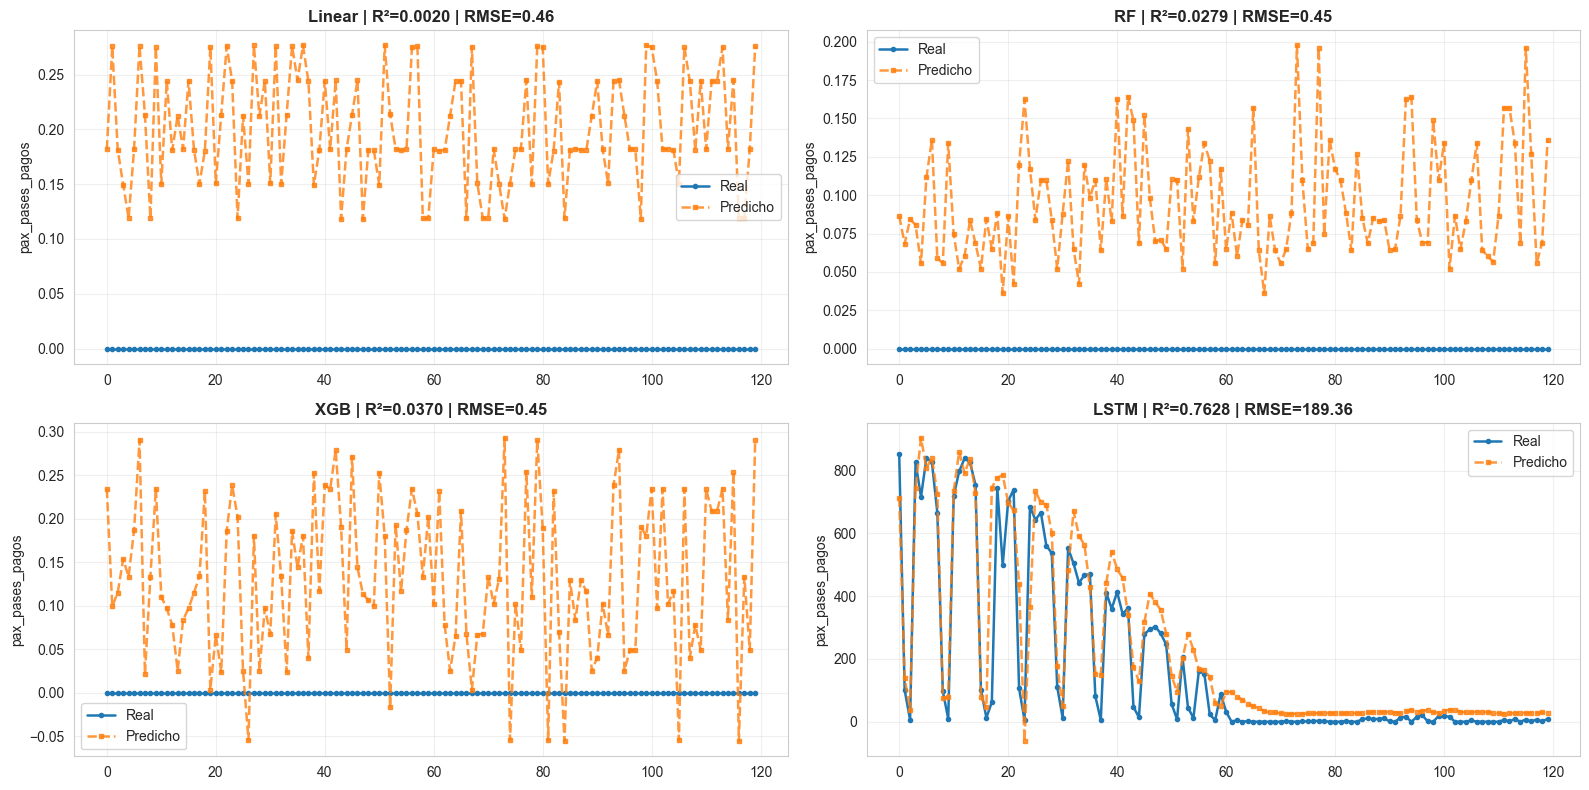


Métricas comparativas:



,R2,MAE,RMSE,MAPE
XGB,0.0370,0.2172,0.4478,78.5562
RF,0.0279,0.2205,0.4499,77.1763
Linear,0.0020,0.2196,0.4558,85.6429
LSTM,0.7628,107.2132,189.3588,301.6889


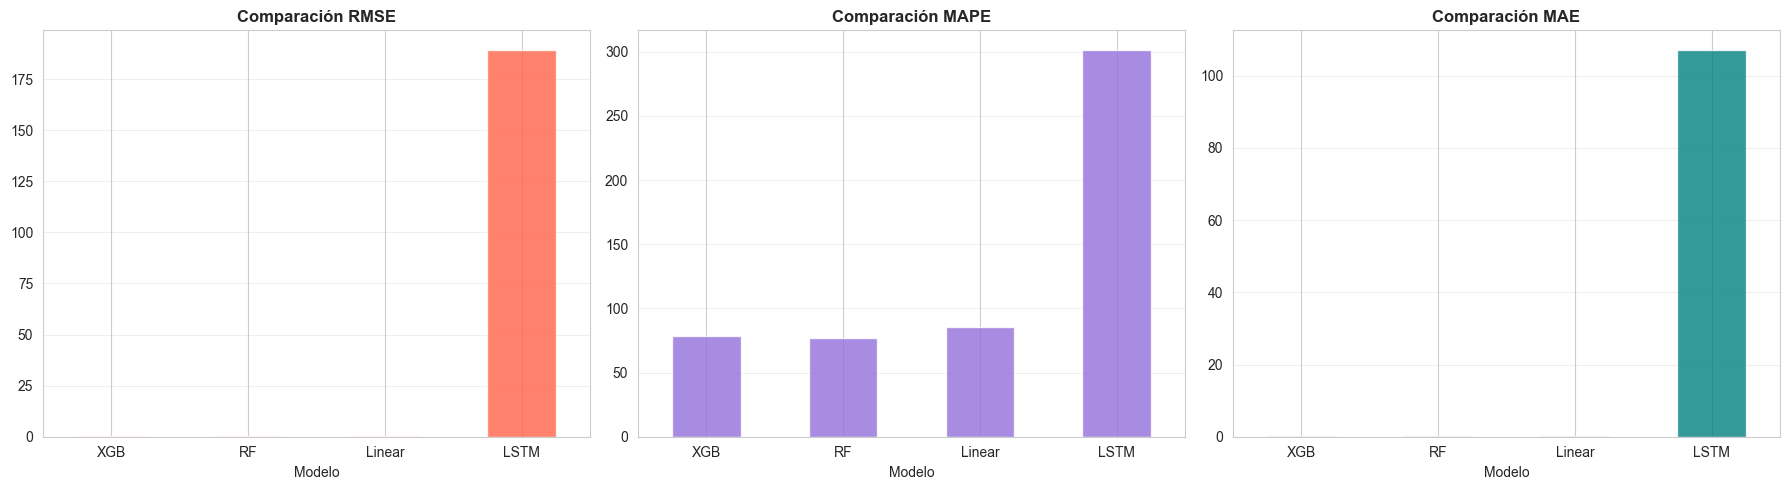

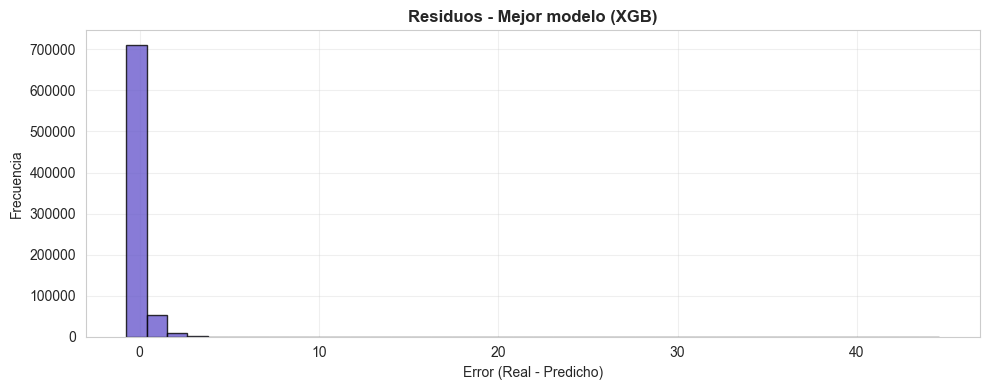


Ranking de modelos (menor RMSE es mejor):

XGB: RMSE=0.45 | MAPE=78.56% | R²=0.0370
RF: RMSE=0.45 | MAPE=77.18% | R²=0.0279
Linear: RMSE=0.46 | MAPE=85.64% | R²=0.0020
LSTM: RMSE=189.36 | MAPE=301.69% | R²=0.7628


In [14]:
# 1) Comparación visual Real vs Predicho
model_names = list(results.keys())
n_models = len(model_names)
ncols = 2
nrows = int(np.ceil(n_models / ncols))

fig, axes = plt.subplots(nrows, ncols, figsize=(16, 4 * nrows))
axes = np.array(axes).reshape(-1)

for idx, name in enumerate(model_names):
    ax = axes[idx]
    y_true_m = np.array(results[name]['y_true'])
    y_pred_m = np.array(results[name]['pred'])
    limit = min(120, len(y_true_m))

    ax.plot(y_true_m[-limit:], 'o-', label='Real', linewidth=1.8, markersize=3)
    ax.plot(y_pred_m[-limit:], 's--', label='Predicho', linewidth=1.8, markersize=3, alpha=0.8)
    ax.set_title(f"{name} | R²={results[name]['R2']:.4f} | RMSE={results[name]['RMSE']:.2f}", fontweight='bold')
    ax.set_ylabel(target_col)
    ax.legend()
    ax.grid(alpha=0.3)

for j in range(idx + 1, len(axes)):
    axes[j].axis('off')

plt.tight_layout()
plt.show()

# 2) Tabla y barras de métricas
metrics_df = pd.DataFrame({
    name: {
        'R2': m['R2'],
        'MAE': m['MAE'],
        'RMSE': m['RMSE'],
        'MAPE': m['MAPE']
    }
    for name, m in results.items()
}).T.sort_values('RMSE')

print("\nMétricas comparativas:\n")
display(metrics_df.round(4))

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
for ax, metric, color in zip(axes, ['RMSE', 'MAPE', 'MAE'], ['tomato', 'mediumpurple', 'teal']):
    metrics_df[metric].plot(kind='bar', ax=ax, color=color, alpha=0.8)
    ax.set_title(f'Comparación {metric}', fontweight='bold')
    ax.set_xlabel('Modelo')
    ax.tick_params(axis='x', rotation=0)
    ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

# 3) Residuos del mejor modelo por RMSE
best_model = metrics_df.index[0]
residuals = np.array(results[best_model]['y_true']) - np.array(results[best_model]['pred'])

plt.figure(figsize=(10, 4))
plt.hist(residuals, bins=40, color='slateblue', alpha=0.8, edgecolor='black')
plt.title(f'Residuos - Mejor modelo ({best_model})', fontweight='bold')
plt.xlabel('Error (Real - Predicho)')
plt.ylabel('Frecuencia')
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

print("\nRanking de modelos (menor RMSE es mejor):\n")
for name in metrics_df.index:
    print(f"{name}: RMSE={metrics_df.loc[name, 'RMSE']:.2f} | MAPE={metrics_df.loc[name, 'MAPE']:.2f}% | R²={metrics_df.loc[name, 'R2']:.4f}")